# Insight 177 replication

This notebook runs the PyTorch replication for all six markets. It produces both the paper-comparable 2015-2025 out-of-sample results and an expanded-history sensitivity run.

The OOS protocol follows Insight 177: for each Tuesday evaluation date, the model is trained only on the preceding 104 weekly observations, excludes the current Managed Money observation, uses price inputs through the current Tuesday, and scores the prediction only after the realized Managed Money value is available.

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import paper_replication
import paper_replication.data as data_module
import paper_replication.evaluate as evaluate_module
importlib.reload(data_module)
evaluate_module = importlib.reload(evaluate_module)
from paper_replication import ReplicationConfig, MARKETS
run_replication = evaluate_module.run_replication

DATA_DIR = PROJECT_ROOT / 'data_required'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'neural_network').mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)

/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication


## Configuration

`futures_only` is the default Managed Money basis. Change it to `combined` only for a sensitivity run. The first rolling fit uses 1,024 full-batch epochs; later windows warm-start from the previous fit and use 36 epochs.

In [2]:
config = ReplicationConfig(data_dir=DATA_DIR, basis='futures_only', train_weeks=104, seed=7)
config

ReplicationConfig(data_dir=PosixPath('/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/data_required'), basis='futures_only', train_weeks=104, hidden_factors=3, first_epochs=1024, rolling_epochs=36, learning_rate=0.01, lambda_w=0.04, lambda_bias=0.01, evaluation_start='2015-01-01', evaluation_end='2025-12-31', seed=7, expanded=False)

## Paper-comparable run

This run retains the two-year warm-up and evaluates forecasts from 2015 through 2025.

In [3]:
paper_run = run_replication(config, expanded=False, progress=True)
paper_metrics = paper_run['metrics']
paper_metrics

Paper replication:   0%|          | 0/384 [00:00<?, ?week/s]

Paper replication:  55%|█████▍    | 211/384 [00:00<00:00, 378.10week/s]

Paper replication:  65%|██████▍   | 249/384 [00:04<00:03, 43.30week/s] 

Paper replication:  69%|██████▉   | 266/384 [00:06<00:03, 29.72week/s]

Paper replication:  72%|███████▏  | 276/384 [00:07<00:04, 24.30week/s]

...

Paper replication:  93%|█████████▎| 359/384 [00:18<00:02,  9.69week/s]

Paper replication:  94%|█████████▍| 360/384 [00:18<00:02,  9.33week/s]

Paper replication:  94%|█████████▍| 361/384 [00:18<00:02,  9.47week/s]

Paper replication: 100%|██████████| 384/384 [00:18<00:00, 20.82week/s]

r2_oos                    0.33507
directional_accuracy      0.71000
observations            900.00000
dtype: float64

In [4]:
paper_predictions = paper_run['predictions']
paper_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_paper_window.csv', index=False)
try:
    paper_run['weekly_panel'].to_parquet(OUTPUT_DIR / 'neural_network' / 'weekly_features_paper_window.parquet', index=False)
except Exception as parquet_error:
    paper_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_paper_window.csv', index=False)
    print(f'Parquet export unavailable ({type(parquet_error).__name__}); saved the weekly panel as CSV instead.')
paper_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_paper_window.csv')
paper_predictions.head()

,market,report_week_tuesday,actual_position,mm_mean_lag,mm_std_lag,predicted_y,y,predicted_position,predicted_position_change,actual_position_change,actual_change,predicted_change
1,BRENT,2015-01-06,142286.0,122360.865385,53496.797195,-0.230725,0.372455,110017.833310,NaN,NaN,NaN,NaN
7,BRENT,2015-01-13,142751.0,123302.173077,53522.557240,-0.080756,0.363376,118979.895412,NaN,NaN,465.0,8962.062102
13,BRENT,2015-01-20,127801.0,124448.019231,53357.286975,-0.021800,0.062840,123284.828176,NaN,NaN,-14950.0,4304.932764
19,BRENT,2015-01-27,129740.0,125184.153846,53118.270394,-0.180797,0.085768,115580.511934,NaN,NaN,1939.0,-7704.316243
25,BRENT,2015-02-03,124499.0,125787.942308,53002.794569,-0.025635,-0.024318,124429.240728,NaN,NaN,-5241.0,8848.728794


## Expanded-history run

This run uses all available weekly dates after the same 104-week warm-up. Its metrics should not be compared directly with the published tables unless the date range is restricted.

In [5]:
expanded_run = run_replication(config, expanded=True, progress=True)
expanded_metrics = expanded_run['metrics']
expanded_metrics

Expanded replication:   0%|          | 0/384 [00:00<?, ?week/s]

Expanded replication:  54%|█████▍    | 209/384 [00:00<00:00, 371.83week/s]

Expanded replication:  64%|██████▍   | 247/384 [00:04<00:03, 42.31week/s] 

Expanded replication:  68%|██████▊   | 263/384 [00:06<00:03, 30.73week/s]

Expanded replication:  71%|███████   | 273/384 [00:07<00:04, 25.54week/s]

...

Expanded replication:  93%|█████████▎| 358/384 [00:15<00:02, 10.29week/s]

Expanded replication:  94%|█████████▍| 360/384 [00:15<00:02, 10.23week/s]

Expanded replication:  94%|█████████▍| 362/384 [00:15<00:01, 11.82week/s]

Expanded replication: 100%|██████████| 384/384 [00:15<00:00, 24.05week/s]

r2_oos                    0.313933
directional_accuracy      0.696272
observations            912.000000
dtype: float64

In [6]:
expanded_predictions = expanded_run['predictions']
expanded_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_expanded.csv', index=False)
try:
    expanded_run['weekly_panel'].to_parquet(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.parquet', index=False)
except BaseException as parquet_error:
    expanded_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.csv', index=False)
    print(f'Parquet export unavailable ({type(parquet_error).__name__}); saved the weekly panel as CSV instead.')
expanded_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_expanded.csv')
expanded_predictions.tail()

,market,report_week_tuesday,actual_position,mm_mean_lag,mm_std_lag,predicted_y,y,predicted_position,predicted_position_change,actual_position_change,actual_change,predicted_change
888,WTI,2017-10-24,239964.0,233611.903846,85998.160088,0.199891,0.073863,250802.133957,NaN,NaN,17830.0,-3169.422766
894,WTI,2017-10-31,295232.0,233522.269231,85500.823700,0.666001,0.721744,290465.930666,NaN,NaN,55268.0,39663.796709
900,WTI,2017-11-07,340269.0,235134.250000,85477.540808,1.220885,1.229969,339492.500690,NaN,NaN,45037.0,49026.570024
906,WTI,2017-11-14,372239.0,239160.730769,85853.750173,1.308520,1.550058,351502.055994,NaN,NaN,31970.0,12009.555305
912,WTI,2017-11-21,339492.0,243936.615385,86592.007340,1.147614,1.103513,343310.784521,NaN,NaN,-32747.0,-8191.271473


## Diagnostics

The plot compares actual and model-predicted normalized Managed Money positions by market. The paper's published figures use position changes for scoring; this plot is a visual diagnostic for level comovement.

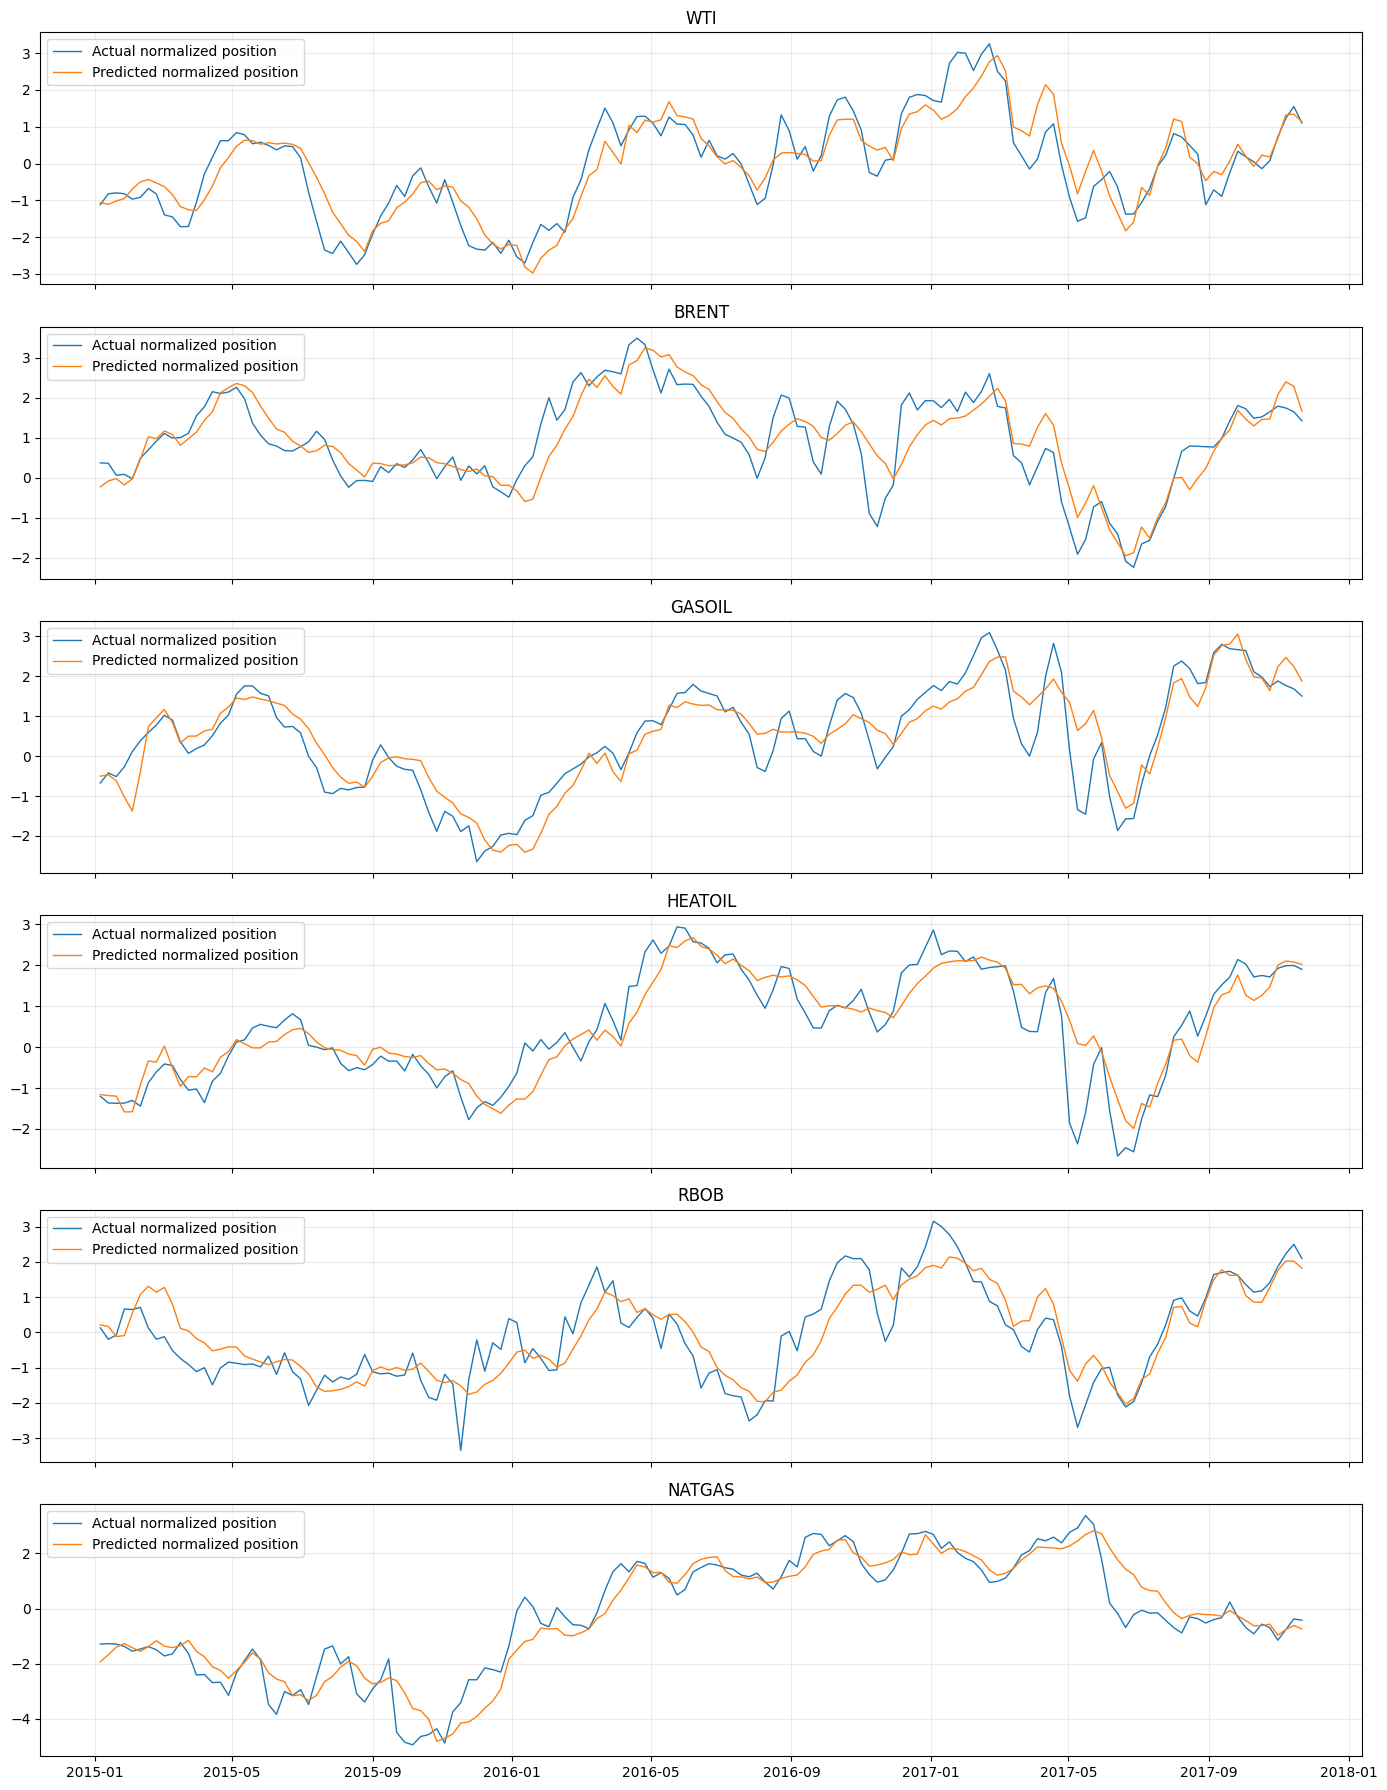

In [7]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(14, 18), sharex=True)
for axis, market in zip(axes, MARKETS):
    subset = paper_predictions.loc[paper_predictions['market'].eq(market)]
    axis.plot(subset['report_week_tuesday'], subset['y'], label='Actual normalized position', linewidth=1)
    axis.plot(subset['report_week_tuesday'], subset['predicted_y'], label='Predicted normalized position', linewidth=1)
    axis.set_title(market)
    axis.grid(alpha=0.25)
    axis.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'neural_network' / 'figures_model_vs_actual_levels.png', dpi=160)
plt.show()

## Checks to record

Compare the paper-window metrics with Insight 177's reported cumulative performance. Differences can arise from the source data vintage, futures roll reconstruction, futures-only versus combined COT basis, missing-settlement handling, and exact implementation details of the regularized bias. Keep the expanded-history results separate from the paper-comparable results.

In [8]:
# Fallback export for environments where pandas/pyarrow versions are incompatible.
expanded_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_expanded.csv', index=False)
expanded_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.csv', index=False)
expanded_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_expanded.csv')
print('Saved expanded predictions, weekly panel, and metrics as CSV files.')

Saved expanded predictions, weekly panel, and metrics as CSV files.
